Imported necessary libraries and models

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

Loaded the loan prediction dataset into a Dataframe for analysis 

In [2]:
df = pd.read_csv(r"C:\Users\KEERTHI SRI S\OneDrive\Desktop\AI_Data_Journey\2Months_of_ML\train_u6lujuX_CVtuZ9i.csv")

Handling missing values and removed unnecessary columns

In [3]:
df.drop('Loan_ID', axis=1, inplace=True)

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

Converted categorical variables into numerical format using encoding

In [4]:
df = pd.get_dummies(df, drop_first=True)

Splithe dataset into training and testing sets

In [ ]:
X = df.drop('Loan_Status_Y', axis=1)
y = df['Loan_Status_Y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scaled features to improve SVM model peformance

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SVM separates data by finding the best possible boundary between different classes

SVM Accuracy: 0.8536585365853658


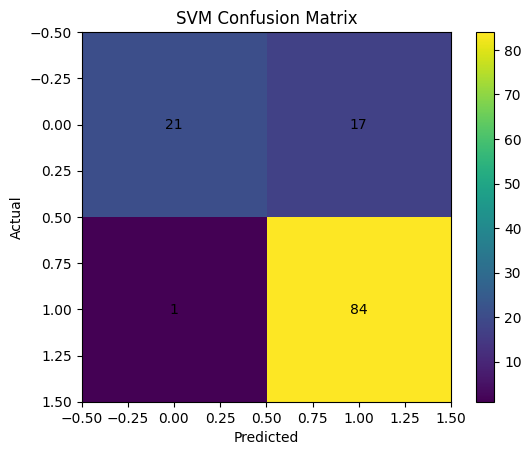

In [9]:
svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
plt.imshow(cm)
plt.title("SVM Confusion Matrix")
plt.colorbar()
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Naive Bayes predicts outcomes based on probability by assuming features are independent

Naive Bayes Accuracy: 0.8455284552845529


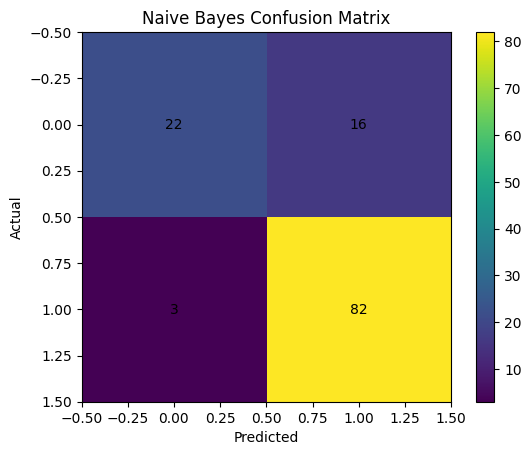

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
cm = confusion_matrix(y_test, y_pred_nb)
plt.imshow(cm)
plt.title("Naive Bayes Confusion Matrix")
plt.colorbar()
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j,i, cm[i][j], ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Removwe target variable to apply unsupervised learning

In [17]:
 X_cluster = df.drop('Loan_Status_Y', axis=1)
 

Used elbow method to determine optimal number of clusters

c:\Users\KEERTHI SRI S\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\KEERTHI SRI S\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\KEERTHI SRI S\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\KEERTHI SRI S\AppData\Local\Programs\Python\Python38\li

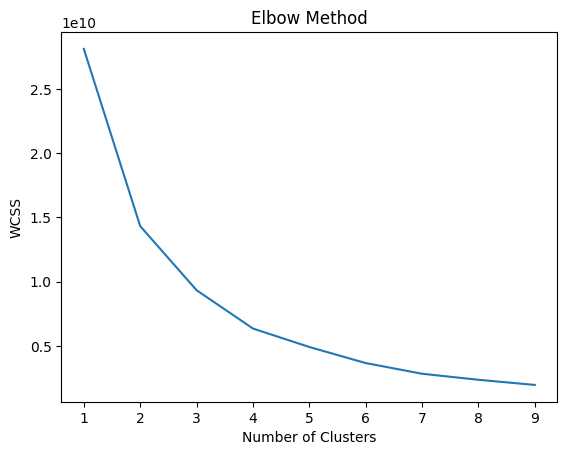

In [19]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")
plt.show()

Observed how data points are distributed across clusters

In [22]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_cluster)
df['Cluster'] = clusters
print(df[['Cluster']].head())
print(df['Cluster'].value_counts())

c:\Users\KEERTHI SRI S\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


   Cluster
0        0
1        0
2        0
3        0
4        0
Cluster
0    607
1      7
Name: count, dtype: int64


Compared performance of SVM and Naive bayes model

In [21]:
print("\nModel Comparison:")
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))


Model Comparison:
SVM: 0.8536585365853658
Naive Bayes: 0.8455284552845529
